# Samples, incidence intervals, and z-score

This notebooks explore the 2016 properties prices across the United Kingdom, and three cities: Newcastle, Cardiff, and Cambridge.

Suggested reading:

- [Introduction to hypothesis testing](https://medium.com/analytics-vidhya/hypothesis-testing-for-dummies-5903cff6e82d)

- [Hypothesis testing for beginners](https://www.analyticsvidhya.com/blog/2021/07/a-simple-guide-to-hypothesis-testing-for-dummies/)
 
- [More advanced statistical discussions](https://www.jasnh.com/a6.htm)

- [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test)


This notebook is structured as follow: 

- [Data preparation](#Upload-and-prepare-the-data)

- [Sample description](#Sample-description-of-prices:-Cambridge,-Newcastle,-and-Cardiff)

- [Surveying prices](#Surveying-the-prices)

- [Would Newcastle residents could consider buying a property in Cambridge?](#Would-Newcastle-residents-could-consider-buying-a-property-in-Cambridge?)

- [Would Cardiff residents would consider buying a property in Cambridge?](#Would-Cardiff-residents-would-consider-buying-a-property-in-Cambridge?)

- [Would Newcastle residents buy in Cardiff?](#Would-Newcastle-residents-buy-in-Cardiff?)

- [Cambridge: exploring further the market with a simulation](#Cambridge:-exploring-further-the-market-with-a-simulation)

- [Newcastle: exploring further the market with a simulation](#Newcastle:-exploring-further-the-market-with-a-simulation)

- [Cardiff : exploring further the market with a simulation](#Cardiff-:-exploring-further-the-market-with-a-simulation)


# Upload and prepare the data
This section prepares the data for our analysis.

In [133]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import seaborn as sns
from statsmodels.stats.weightstats import ttest_ind


pd.option_context('mode.use_inf_as_na', True)
 


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/united-kingdom-real-estate-and-population-data/data_2014.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2005.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2006.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2013.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2011.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2001.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2015.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_month_clean.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2017.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2016.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2012.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2007.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2004.csv
/kaggle/input/unit

In [71]:
data = pd.read_csv('/kaggle/input/united-kingdom-real-estate-and-population-data/data_2017.csv')
print("rows and columns : " , data.shape)

rows and columns :  (178818, 17)


In [72]:
data.dtypes

Unnamed: 0.1          int64
Unnamed: 0            int64
Code                 object
Name                 object
Geography            object
Area (sq km)        float64
Price                 int64
Date of Transfer     object
Property Type        object
Old/New              object
Duration             object
PPDCategory Type     object
pp_sq_m             float64
est_pop             float64
Year                  int64
Month                 int64
Day                   int64
dtype: object

In [73]:
data.head()

,Unnamed: 0.1,Unnamed: 0,Code,Name,Geography,Area (sq km),Price,Date of Transfer,Property Type,Old/New,Duration,PPDCategory Type,pp_sq_m,est_pop,Year,Month,Day
0,5218252,46522,E06000005,DARLINGTON,Unitary Authority,197.4779,112000,2017-05-19,T,N,F,A,534.66236,NaN,2017,5,19
1,5218253,46523,E06000005,DARLINGTON,Unitary Authority,197.4779,145000,2017-05-17,S,N,F,A,534.66236,NaN,2017,5,17
2,5218254,46524,E06000005,DARLINGTON,Unitary Authority,197.4779,105000,2017-06-09,T,N,F,A,534.66236,NaN,2017,6,9
3,5218255,46525,E06000005,DARLINGTON,Unitary Authority,197.4779,123500,2017-05-26,F,N,L,A,534.66236,NaN,2017,5,26
4,5218256,46526,E06000005,DARLINGTON,Unitary Authority,197.4779,170000,2017-05-19,T,N,F,A,534.66236,NaN,2017,5,19


In [74]:
cols = ['Name', 'Price','Property Type']
prices = data[cols]
prices.dtypes

Name             object
Price             int64
Property Type    object
dtype: object

In [75]:
prices.describe()

,Price
count,1.788180e+05
mean,3.583895e+05
std,1.330703e+06
min,1.000000e+00
25%,1.300000e+05
50%,2.050000e+05
75%,3.450000e+05
max,9.876539e+07


In [76]:
prices['Name'].unique()

array(['DARLINGTON', 'HARTLEPOOL', 'MIDDLESBROUGH', 'STOCKTON-ON-TEES',
       'GATESHEAD', 'NEWCASTLE UPON TYNE', 'SUNDERLAND', 'BLACKPOOL',
       'WARRINGTON', 'BARROW-IN-FURNESS', 'CARLISLE', 'BOLTON', 'BURY',
       'MANCHESTER', 'OLDHAM', 'ROCHDALE', 'SALFORD', 'STOCKPORT',
       'WIGAN', 'BURNLEY', 'CHORLEY', 'LANCASTER', 'PRESTON',
       'ROSSENDALE', 'LIVERPOOL', 'WIRRAL', 'YORK', 'HARROGATE',
       'SCARBOROUGH', 'SELBY', 'BARNSLEY', 'DONCASTER', 'ROTHERHAM',
       'SHEFFIELD', 'BRADFORD', 'LEEDS', 'WAKEFIELD', 'DERBY',
       'LEICESTER', 'NOTTINGHAM', 'CHESTERFIELD', 'HIGH PEAK', 'BOSTON',
       'LINCOLN', 'MANSFIELD', 'STOKE-ON-TRENT', 'LICHFIELD', 'STAFFORD',
       'TAMWORTH', 'RUGBY', 'WARWICK', 'BIRMINGHAM', 'COVENTRY', 'DUDLEY',
       'SOLIHULL', 'WALSALL', 'WOLVERHAMPTON', 'BROMSGROVE', 'REDDITCH',
       'WORCESTER', 'BEDFORD', 'LUTON', 'PETERBOROUGH', 'SOUTHEND-ON-SEA',
       'CAMBRIDGE', 'BASILDON', 'BRAINTREE', 'BRENTWOOD', 'CHELMSFORD',
       'COLCHESTER

In [77]:
prices_cam = prices.loc[prices['Name'].str.contains('CAMBRIDGE'), :]
prices_cam.shape

(1639, 3)

In [78]:
prices_new = prices.loc[prices['Name'].str.contains('NEWCASTLE UPON TYNE'), :]
prices_new.shape

(2419, 3)

In [79]:
prices_car = prices.loc[prices['Name'].str.contains('CARDIFF'), :]
prices_car.shape

(2272, 3)

# Sample description of prices: Cambridge, Newcastle, and Cardiff

We explore the distribution for each city - we consider the properties sold in 2016 as a sample. We first visualise - without any outliers - the sample in a boxplot. No Normal distribution  or other parametrisation is imposed. We discover Cambridge appears to have demonstrate the highest disparity in prices in comparison toe Newcastle-Upon-Tyne, and Cardiff.

Applying the a log10 scale to the data shows Cambridge has overall a sample that was the most expensive in comparison to Newcastle and Cardiff. 

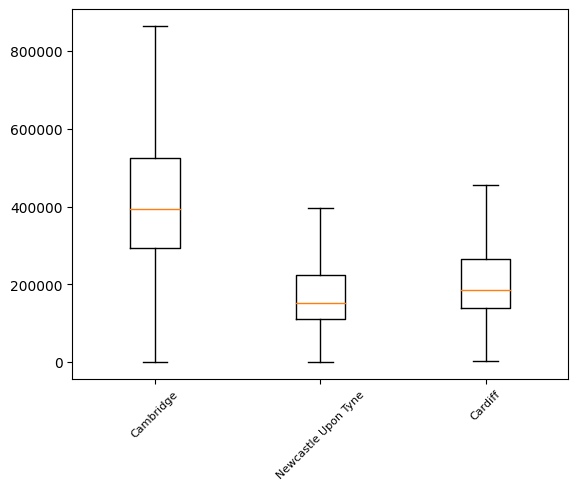

In [80]:
data = [prices_cam.Price, prices_new.Price, prices_car.Price]
fig, ax = plt.subplots()
ax.boxplot(data, 0,'')
ax.set_xticklabels(['Cambridge', "Newcastle Upon Tyne", "Cardiff"],
                    rotation=45, fontsize=8)
plt.show()

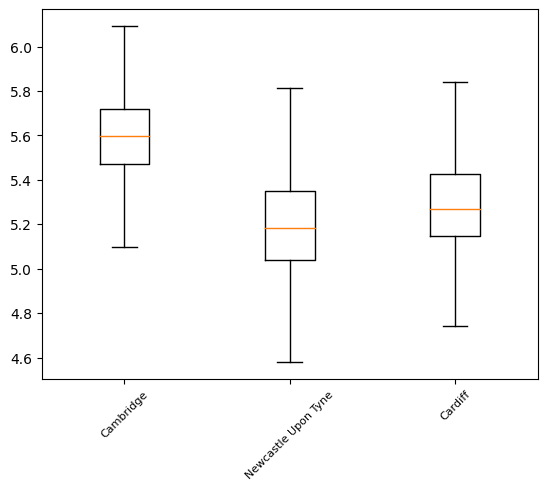

In [81]:
data = [np.log10(prices_cam.Price), np.log10(prices_new.Price), np.log10(prices_car.Price)]
fig, ax = plt.subplots()
ax.boxplot(data, 0,'')
ax.set_xticklabels(['Cambridge', "Newcastle Upon Tyne", "Cardiff"],
                    rotation=45, fontsize=8)
plt.show()

In [82]:
temp = pd.DataFrame()
temp['Cambridge'] = prices_cam.describe()
temp['Newcastle'] = prices_new.describe()
temp['Cardiff'] = prices_car.describe()

temp

,Cambridge,Newcastle,Cardiff
count,1.639000e+03,2.419000e+03,2.272000e+03
mean,4.853539e+05,2.135305e+05,2.715237e+05
std,7.475032e+05,3.818970e+05,6.580335e+05
min,1.000000e+02,1.000000e+02,3.500000e+03
25%,2.950000e+05,1.100000e+05,1.399988e+05
50%,3.950000e+05,1.530000e+05,1.850000e+05
75%,5.250000e+05,2.250000e+05,2.660000e+05
max,1.853410e+07,8.538000e+06,1.682620e+07


## Cambridge

/tmp/ipykernel_33/1253151563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices_cam['price_log10'] = np.log10(prices_cam['Price'])
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log10', ylabel='Count'>

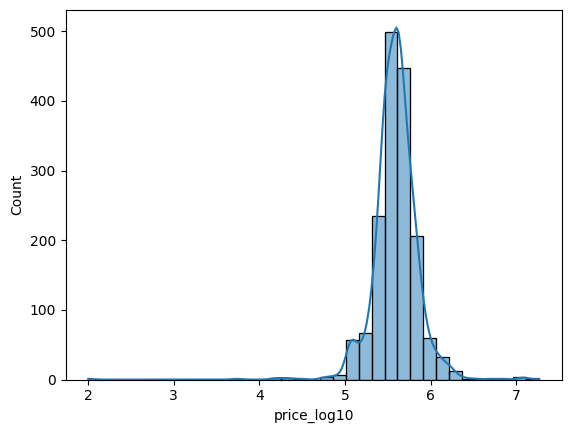

In [83]:
prices_cam['price_log10'] = np.log10(prices_cam['Price'])
sns.histplot(data=prices_cam, x="price_log10", bins = 35, kde = True)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count    1.639000e+03
mean     4.853539e+05
std      7.475032e+05
min      1.000000e+02
25%      2.950000e+05
50%      3.950000e+05
75%      5.250000e+05
max      1.853410e+07
Name: Price, dtype: float64

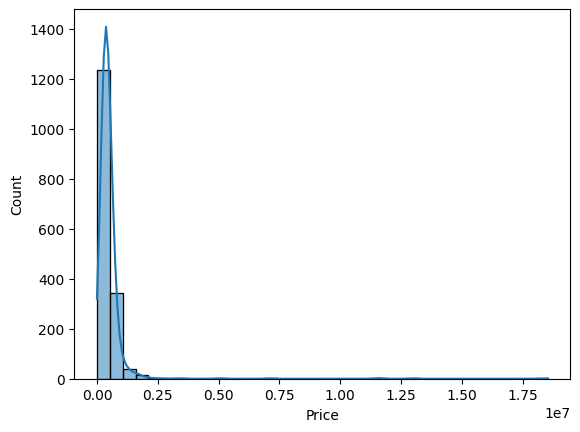

In [84]:
sns.histplot(data=prices_cam, x="Price", bins = 35, kde = True)
prices_cam.describe()['Price']

## Newcastle Upon Tyne

/tmp/ipykernel_33/1492758376.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices_new['price_log10'] = np.log10(prices_new['Price'])
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log10', ylabel='Count'>

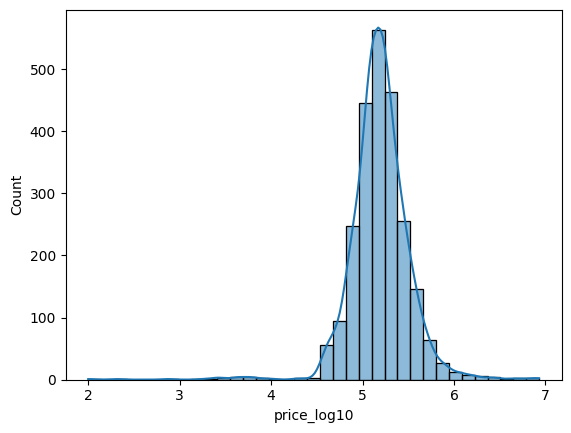

In [85]:
prices_new['price_log10'] = np.log10(prices_new['Price'])
sns.histplot(data=prices_new, x="price_log10", bins = 35, kde = True)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count    2.419000e+03
mean     2.135305e+05
std      3.818970e+05
min      1.000000e+02
25%      1.100000e+05
50%      1.530000e+05
75%      2.250000e+05
max      8.538000e+06
Name: Price, dtype: float64

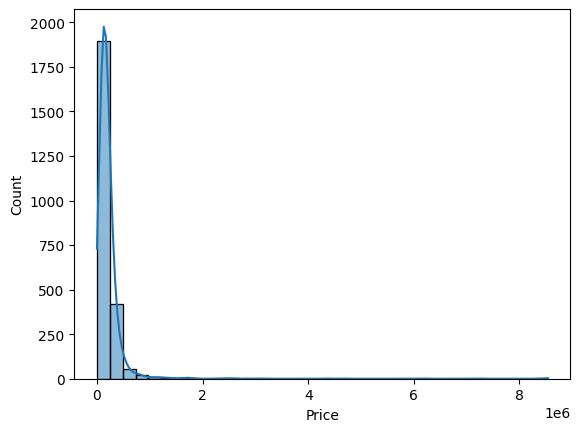

In [86]:
sns.histplot(data=prices_new, x="Price", bins = 35, kde = True)
prices_new.describe()['Price']

## Cardiff

/tmp/ipykernel_33/1944608503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices_car['price_log10'] = np.log10(prices_car['Price'])
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log10', ylabel='Count'>

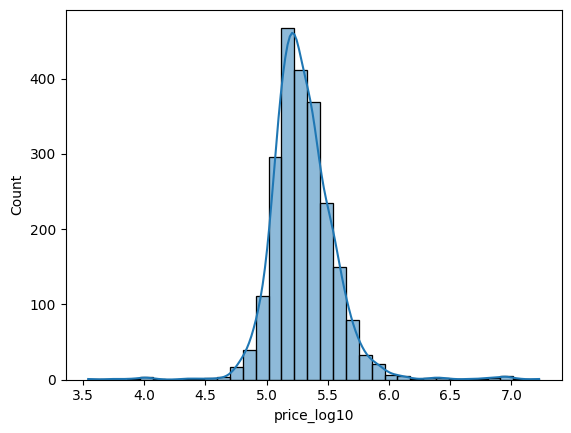

In [87]:
prices_car['price_log10'] = np.log10(prices_car['Price'])
sns.histplot(data=prices_car, x="price_log10", bins = 35, kde = True)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count    2.272000e+03
mean     2.715237e+05
std      6.580335e+05
min      3.500000e+03
25%      1.399988e+05
50%      1.850000e+05
75%      2.660000e+05
max      1.682620e+07
Name: Price, dtype: float64

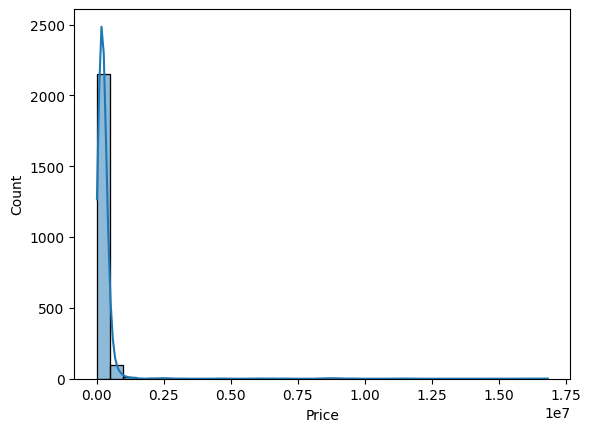

In [88]:
sns.histplot(data=prices_car, x="Price", bins = 35, kde = True)
prices_car.describe()['Price']

# Surveying the prices

We are assuming the exchange of properties is a sample, helping estimating the values of properties in 2016. We use a [confidence intervals analysis](https://www.analyticsvidhya.com/blog/2022/01/understanding-confidence-intervals-with-python/).

In [89]:
confidence_level = 0.95
conf_level_95 = 0.95
conf_level_95 = 0.90


## Cambridge

In [90]:
mean = prices_cam['Price'].describe()['mean']
std  = prices_cam['Price'].describe()['std']
df = prices_cam.shape[0] - 1
alpha = (1 - confidence_level) / 2
 
# t-value from the t-distribution table
z_critical_value = stats.norm.ppf(q = 0.95) 
 
margin_of_error = z_critical_value * (std / math.sqrt(prices_cam.shape[0]))
 
ll_cam_95 = mean - margin_of_error
ul_cam_95 = mean + margin_of_error


 
print(f"Confidence Interval: ({ll_cam_95}, {ul_cam_95})")
print(f"Z critical value: ({z_critical_value})")


Confidence Interval: (454983.51660221815, 515724.36259241274)
Z critical value: (1.6448536269514722)


In [91]:
mean = prices_cam['Price'].describe()['mean']
std  = prices_cam['Price'].describe()['std']
df = prices_cam.shape[0] - 1
alpha = (1 - confidence_level) / 2
 
# t-value from the t-distribution table
z_critical_value = stats.norm.ppf(q = 0.90) 
 
margin_of_error = z_critical_value * (std / math.sqrt(prices_cam.shape[0]))
 
ll_cam_90 = mean - margin_of_error
ul_cam_90 = mean + margin_of_error
 
print(f"Confidence Interval: ({ll_cam_90}, {ul_cam_90})")
print(f"Z critical value: ({z_critical_value})")


Confidence Interval: (461691.4917673804, 509016.3874272505)
Z critical value: (1.2815515655446004)


## Newcastle Upon Tyne

In [92]:
mean = prices_new['Price'].describe()['mean']
std  = prices_new['Price'].describe()['std']
df = prices_new.shape[0] - 1
alpha = (1 - confidence_level) / 2
 
# t-value from the t-distribution table
z_critical_value = stats.norm.ppf(q = 0.95) 
 
margin_of_error = z_critical_value * (std / math.sqrt(prices_new.shape[0]))
 
ll_new_95 = mean - margin_of_error
ul_new_95 = mean + margin_of_error
 
print(f"Confidence Interval: ({ll_new_95}, {ul_new_95})")
print(f"Z critical value: ({z_critical_value})")


Confidence Interval: (200758.64586382065, 226302.44880339722)
Z critical value: (1.6448536269514722)


In [93]:
mean = prices_new['Price'].describe()['mean']
std  = prices_new['Price'].describe()['std']
df = prices_new.shape[0] - 1
alpha = (1 - confidence_level) / 2
 
# t-value from the t-distribution table
z_critical_value = stats.norm.ppf(q = 0.90) 
 
margin_of_error = z_critical_value * (std / math.sqrt(prices_new.shape[0]))
 
ll_new_90 = mean - margin_of_error
ul_new_90 = mean + margin_of_error
 
print(f"Confidence Interval: ({ll_new_90}, {ul_new_90})")
print(f"Z critical value: ({z_critical_value})")


Confidence Interval: (203579.60090567401, 223481.49376154385)
Z critical value: (1.2815515655446004)


## Cardiff

In [94]:
mean = prices_car['Price'].describe()['mean']
std  = prices_car['Price'].describe()['std']
df = prices_car.shape[0] - 1
alpha = (1 - confidence_level) / 2
 
# t-value from the t-distribution table
z_critical_value = stats.norm.ppf(q = 0.95) 
 
margin_of_error = z_critical_value * (std / math.sqrt(prices_car.shape[0]))
 
ll_car_95 = mean - margin_of_error
ul_car_95 = mean + margin_of_error
 
print(f"Confidence Interval: ({ll_car_95}, {ul_car_95})")
print(f"Z critical value: ({z_critical_value})")


Confidence Interval: (248816.13627364195, 294231.32235311856)
Z critical value: (1.6448536269514722)


In [95]:
mean = prices_car['Price'].describe()['mean']
std  = prices_car['Price'].describe()['std']
df = prices_car.shape[0] - 1
alpha = (1 - confidence_level) / 2
 
# t-value from the t-distribution table
z_critical_value = stats.norm.ppf(q = 0.90) 
 
margin_of_error = z_critical_value * (std / math.sqrt(prices_car.shape[0]))
 
ll_car_90 = mean - margin_of_error
ul_car_90 = mean + margin_of_error
 
print(f"Confidence Interval: ({ll_car_90}, {ul_car_90})")
print(f"Z critical value: ({z_critical_value})")


Confidence Interval: (253831.60708864394, 289215.8515381166)
Z critical value: (1.2815515655446004)


## Summary and findings

When we narrow  the level of confidence we narrow the error. The outliers values appears to impact on the reduction of the errors greatly. The error reduction appears to be quite large for each city, approximately greater than 15,000 (GBP).

In [96]:
ints = np.array([['Cambridge',0.95,ll_cam_95, ul_cam_95], 
                 ['Cambridge',0.90,ll_cam_90, ul_cam_90],
                 ['Newcastle',0.95,ll_new_95, ul_new_95], 
                 ['Newcastle',0.90,ll_new_90, ul_new_90],
                 ['Cardiff',0.95,ll_car_95, ul_car_95], 
                 ['Cardiff',0.90,ll_car_90, ul_car_90]])

ints = pd.DataFrame(ints, columns=['City', 'Confidence level','Lower limit', 'Upper limit'])
ints['Upper limit'] = ints['Upper limit'].astype('float')
ints['Lower limit'] = ints['Lower limit'].astype('float')
ints['interval'] = ints['Upper limit'] - ints['Lower limit']
ints

,City,Confidence level,Lower limit,Upper limit,interval
0,Cambridge,0.95,454983.516602,515724.362592,60740.845990
1,Cambridge,0.9,461691.491767,509016.387427,47324.895660
2,Newcastle,0.95,200758.645864,226302.448803,25543.802940
3,Newcastle,0.9,203579.600906,223481.493762,19901.892856
4,Cardiff,0.95,248816.136274,294231.322353,45415.186079
5,Cardiff,0.9,253831.607089,289215.851538,35384.244449


# Would Newcastle residents could consider buying a property in Cambridge?



In [97]:
temp = pd.DataFrame()
temp['Cambridge'] = prices_cam['Price'].describe()
temp['Newcastle'] = prices_new['Price'].describe()
temp

,Cambridge,Newcastle
count,1.639000e+03,2.419000e+03
mean,4.853539e+05,2.135305e+05
std,7.475032e+05,3.818970e+05
min,1.000000e+02,1.000000e+02
25%,2.950000e+05,1.100000e+05
50%,3.950000e+05,1.530000e+05
75%,5.250000e+05,2.250000e+05
max,1.853410e+07,8.538000e+06


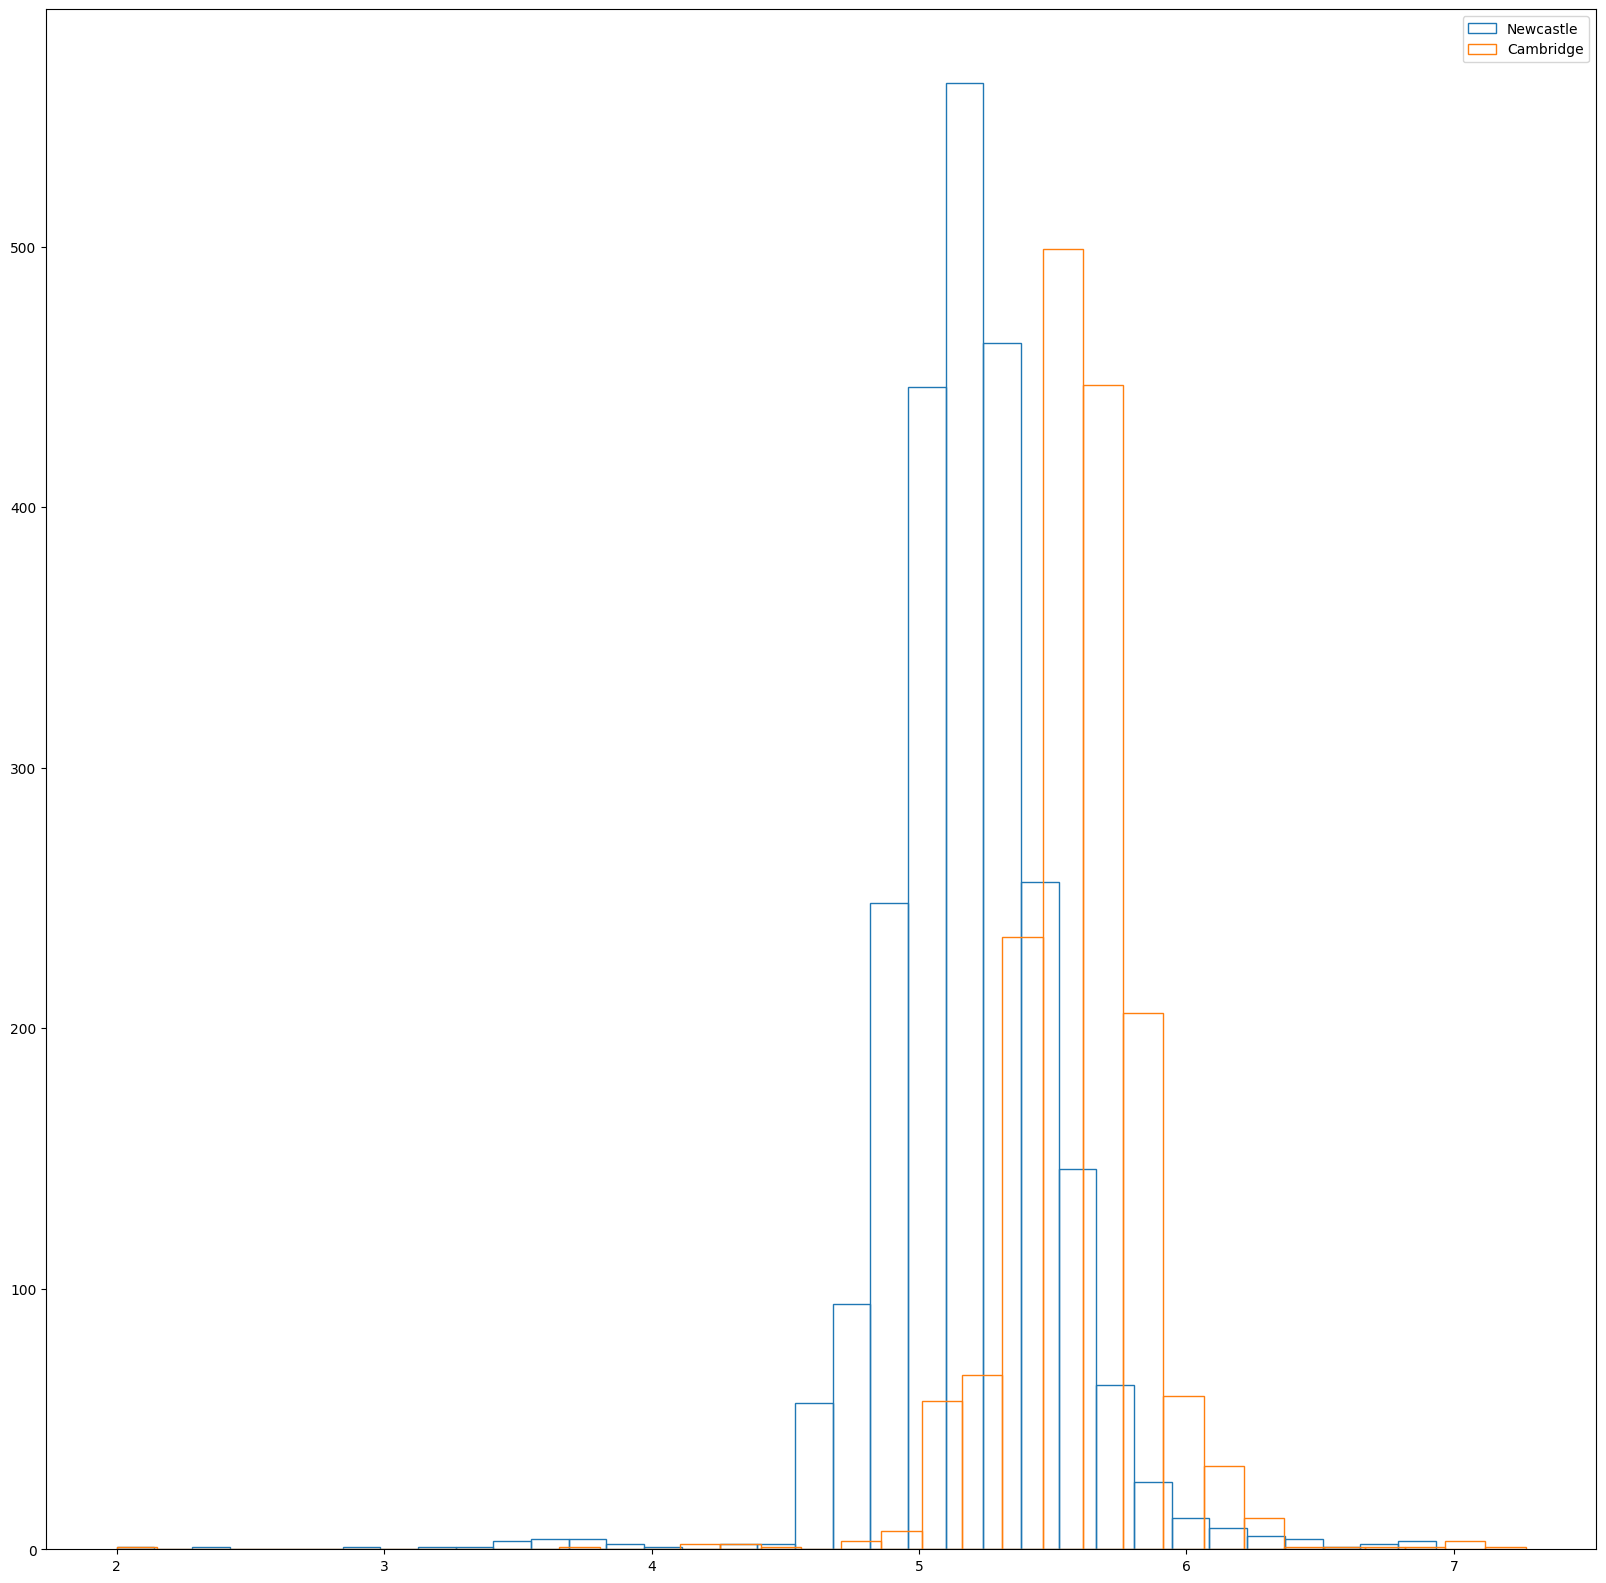

In [117]:
fig, ax = plt.subplots(figsize=(20,20))
style = {'facecolor': 'none', 'edgecolor': 'C0', 'linewidth': 1}
plt.hist(prices_new['price_log10'], label='Newcastle', bins=35, **style)
style = {'facecolor': 'none', 'edgecolor': 'C1', 'linewidth': 1}
plt.hist(prices_cam['price_log10'], label='Cambridge', bins=35, **style)
plt.legend()

We make the hypothesis living in Newcastle does not impact purchasing a property in Newcastle.

$H_0$ is _"Living in Newcastle does not impact on purchasing a property in Newcastle"_.  

$H_1$ is _"Living in Newcastle impact on purchasing a property in Newcastle"_. 

We use a p-value of 0.05. 

M = is the mean sample from 2016

mu = population mean

sigma = population standard deviation

In [141]:
n = prices_cam.shape[0]
mu = prices_cam['Price'].describe()['mean']
sigma  = prices_cam['Price'].describe()['std']
M = prices_new['Price'].describe()['mean']
denominator = sigma / math.sqrt(n)
numerator   = mu - M
Z           = numerator / denominator
Z


14.721879004694381

In [142]:
import scipy.stats

#find p-value for two-tailed test
p_value = scipy.stats.norm.sf(abs(Z))*2
print("p value " , p_value)
if p_value < 0.05:
    print("Reject Null hypothesis")
else:
    print("Fail to reject Null hypothesis")


p value  4.665153910952654e-49
Reject Null hypothesis


As the p-value is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected. This means that living in Newcastle may impact on purchasing a property in Newcastle. However, further research on other aspects that may affect the purchase of property needs to be explored.



[The standardise measure of the effect](https://en.wikipedia.org/wiki/Effect_size#Cohen.27s_d) is computed.

In [125]:
# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
 # calculate the size of samples
 n1, n2 = len(d1), len(d2)
 # calculate the variance of the samples
 s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
 # calculate the pooled standard deviation
 s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
 # calculate the means of the samples
 u1, u2 = np.mean(d1), np.mean(d2)
 # calculate the effect size
 return abs((u1 - u2) / s)

In [130]:
cohen_d = cohend(prices_cam['Price'], prices_new['Price'])
print("d value : ", cohen_d)
if cohen_d == 0 :
    print('no effect')
elif cohen_d < 0.20:
    print('small effect')
elif cohen_d < 0.80:
    print('medium effect')
elif cohen_d < 1:
    print('large effect')

d value :  0.4861748845746366
medium effect


We are completing a t-test with the following hypothesis.

$H_0 = \mu_{cambridge} = \mu_{newcastle}$

$H_1 = \mu_{cambridge} \neq \mu_{newcastle}$

$p  = 0.05$

We have shown that both distributions have not the same paramteters. The p-value is $9e-51$, which is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected.  The mean average of Cambridge and Newcastle are not equal. 



In [135]:
ttest_ind(prices_cam['Price'], prices_new['Price'])

(15.196511721032538, 9.10480558150232e-51, 4056.0)

# Would Cardiff residents would consider buying a property in Cambridge?



In [139]:
temp = pd.DataFrame()
temp['Cambridge'] = prices_cam['Price'].describe()
temp['Cardiff'] = prices_car['Price'].describe()
temp

,Cambridge,Cardiff
count,1.639000e+03,2.272000e+03
mean,4.853539e+05,2.715237e+05
std,7.475032e+05,6.580335e+05
min,1.000000e+02,3.500000e+03
25%,2.950000e+05,1.399988e+05
50%,3.950000e+05,1.850000e+05
75%,5.250000e+05,2.660000e+05
max,1.853410e+07,1.682620e+07


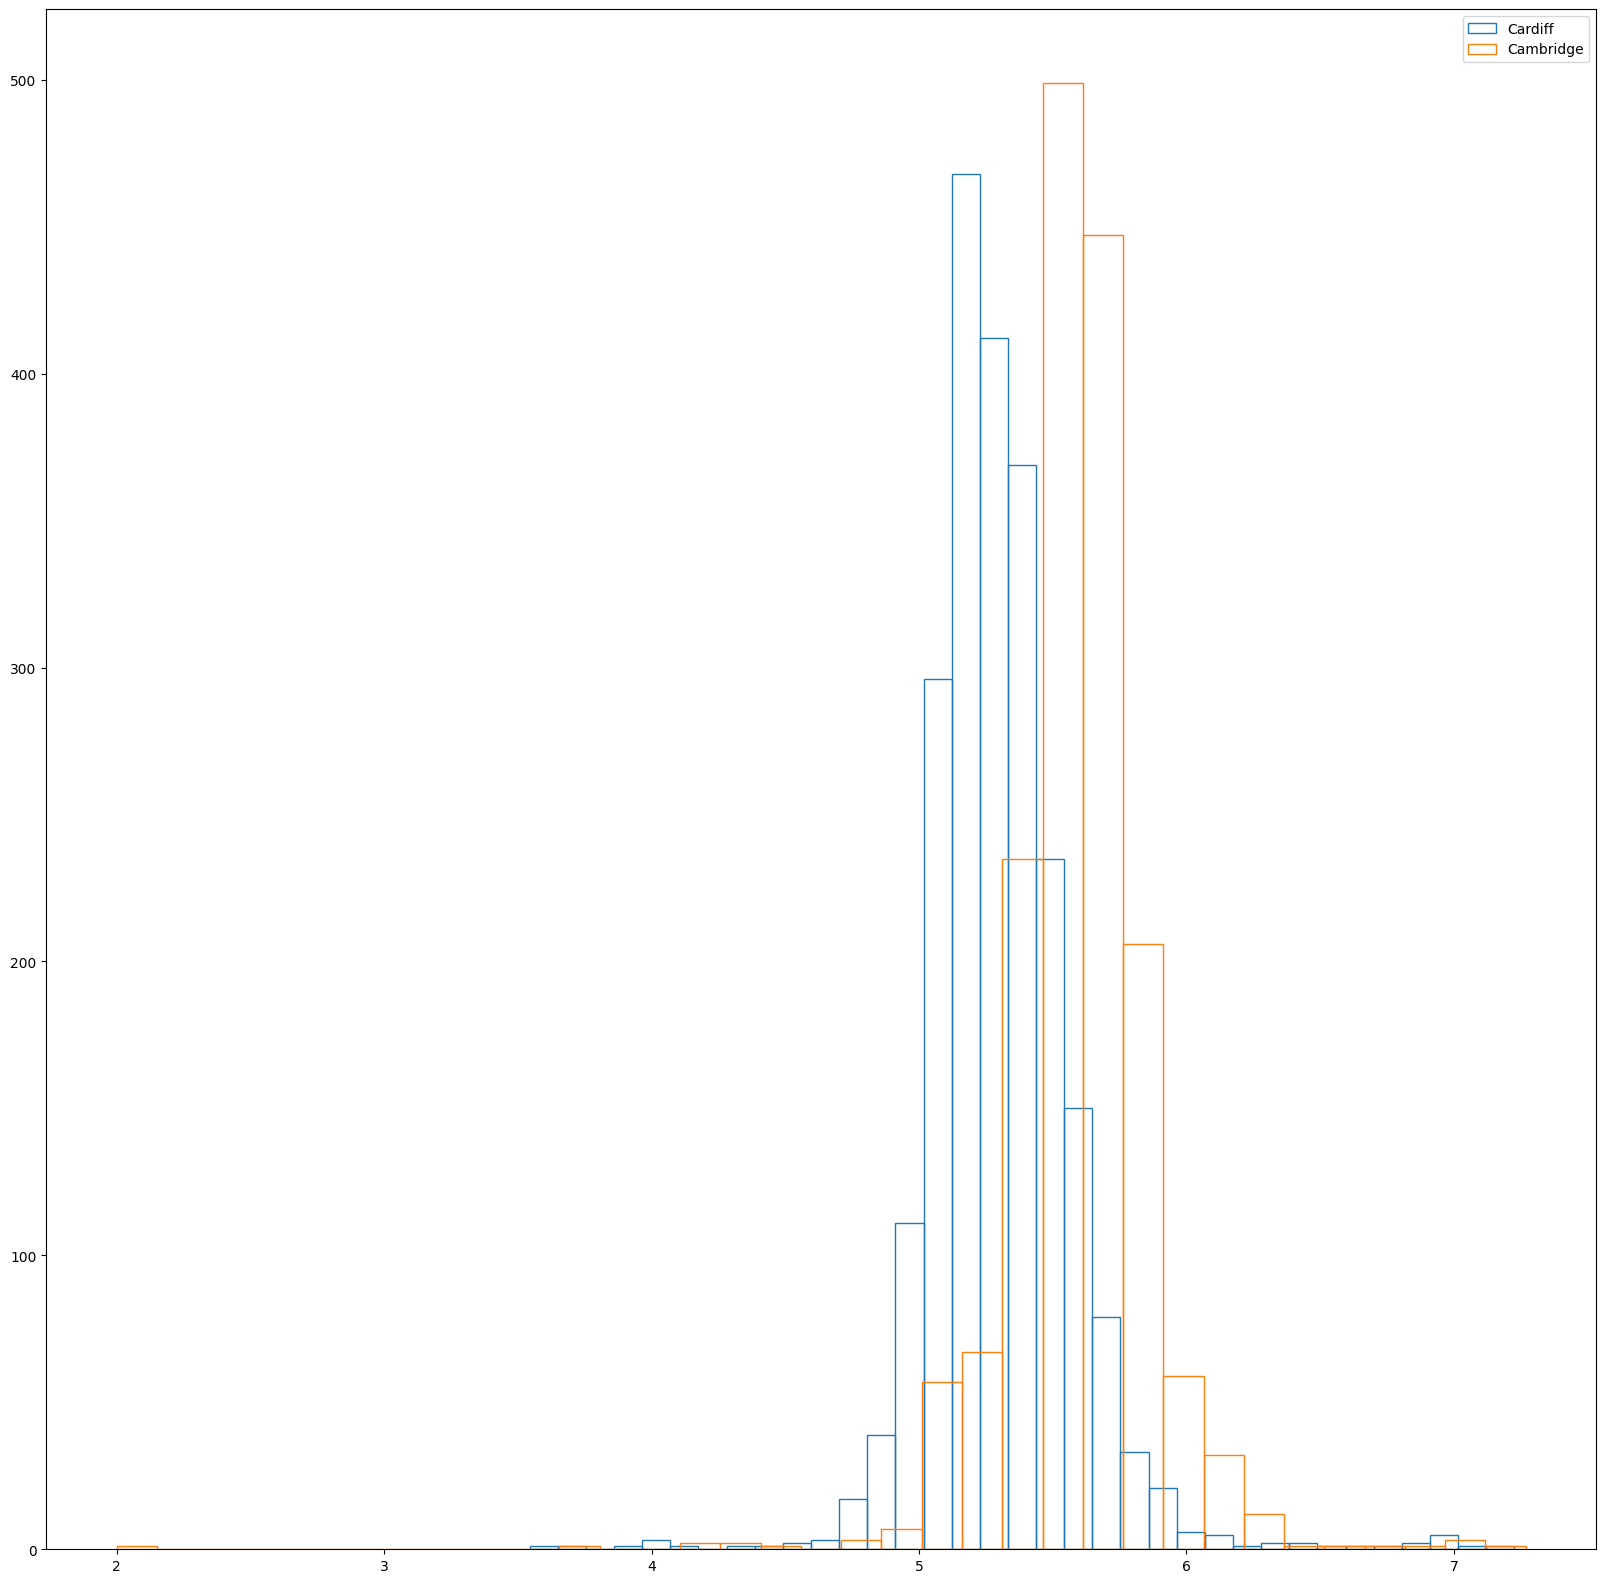

In [140]:
fig, ax = plt.subplots(figsize=(20,20))
style = {'facecolor': 'none', 'edgecolor': 'C0', 'linewidth': 1}
plt.hist(prices_car['price_log10'], label='Cardiff', bins=35, **style)
style = {'facecolor': 'none', 'edgecolor': 'C1', 'linewidth': 1}
plt.hist(prices_cam['price_log10'], label='Cambridge', bins=35, **style)
plt.legend()

We make the hypothesis living in Newcastle does not impact purchasing a property in Newcastle.

$H_0$ is _"Living in Cardiff does not impact on purchasing a property in Newcastle"_.  

$H_1$ is _"Living in Cardiff impact on purchasing a property in Newcastle"_. 

We use a p-value of 0.05. 

M = is the mean sample from 2016

mu = population mean

sigma = population standard deviation

In [143]:
n = prices_cam.shape[0]
mu = prices_cam['Price'].describe()['mean']
sigma  = prices_cam['Price'].describe()['std']
M = prices_car['Price'].describe()['mean']
denominator = sigma / math.sqrt(n)
numerator   = mu - M
Z           = numerator / denominator
Z


11.580984466173053

In [144]:
import scipy.stats

#find p-value for two-tailed test
p_value = scipy.stats.norm.sf(abs(Z))*2
print("p value " , p_value)
if p_value < 0.05:
    print("Reject Null hypothesis")
else:
    print("Fail to reject Null hypothesis")


p value  5.145175685248179e-31
Reject Null hypothesis


As the p-value is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected. This means that living in Cardiff may impact on purchasing a property in Newcastle. However, further research on other aspects that may affect the purchase of property needs to be explored.



[The standardise measure of the effect](https://en.wikipedia.org/wiki/Effect_size#Cohen.27s_d) is computed.

In [146]:
# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
 # calculate the size of samples
 n1, n2 = len(d1), len(d2)
 # calculate the variance of the samples
 s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
 # calculate the pooled standard deviation
 s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
 # calculate the means of the samples
 u1, u2 = np.mean(d1), np.mean(d2)
 # calculate the effect size
 return abs((u1 - u2) / s)

In [161]:
cohen_d = cohend(prices_cam['Price'], prices_car['Price'])
print("d value : ", cohen_d)
if cohen_d == 0 :
    print('no effect')
elif cohen_d < 0.20:
    print('small effect')
elif cohen_d < 0.80:
    print('medium effect')
elif cohen_d < 1:
    print('large effect')

d value :  0.3068200875552179
medium effect


We are completing a t-test with the following hypothesis.

$H_0 = \mu_{cambridge} = \mu_{cardiff}$

$H_1 = \mu_{cambridge} \neq \mu_{cardiff}$

$p  = 0.05$

We have shown that both distributions have not the same paramteters. The p-value is $4.8e-21$, which is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected.  The mean average of Cambridge and Cardiff are not equal. 



In [148]:
ttest_ind(prices_cam['Price'], prices_car['Price'])

(9.467460936406631, 4.810192298011503e-21, 3909.0)

# Would Newcastle residents buy in Cardiff?



In [149]:
temp = pd.DataFrame()
temp['Cardiff'] = prices_car['Price'].describe()
temp['Newcastle'] = prices_new['Price'].describe()
temp

,Cardiff,Newcastle
count,2.272000e+03,2.419000e+03
mean,2.715237e+05,2.135305e+05
std,6.580335e+05,3.818970e+05
min,3.500000e+03,1.000000e+02
25%,1.399988e+05,1.100000e+05
50%,1.850000e+05,1.530000e+05
75%,2.660000e+05,2.250000e+05
max,1.682620e+07,8.538000e+06


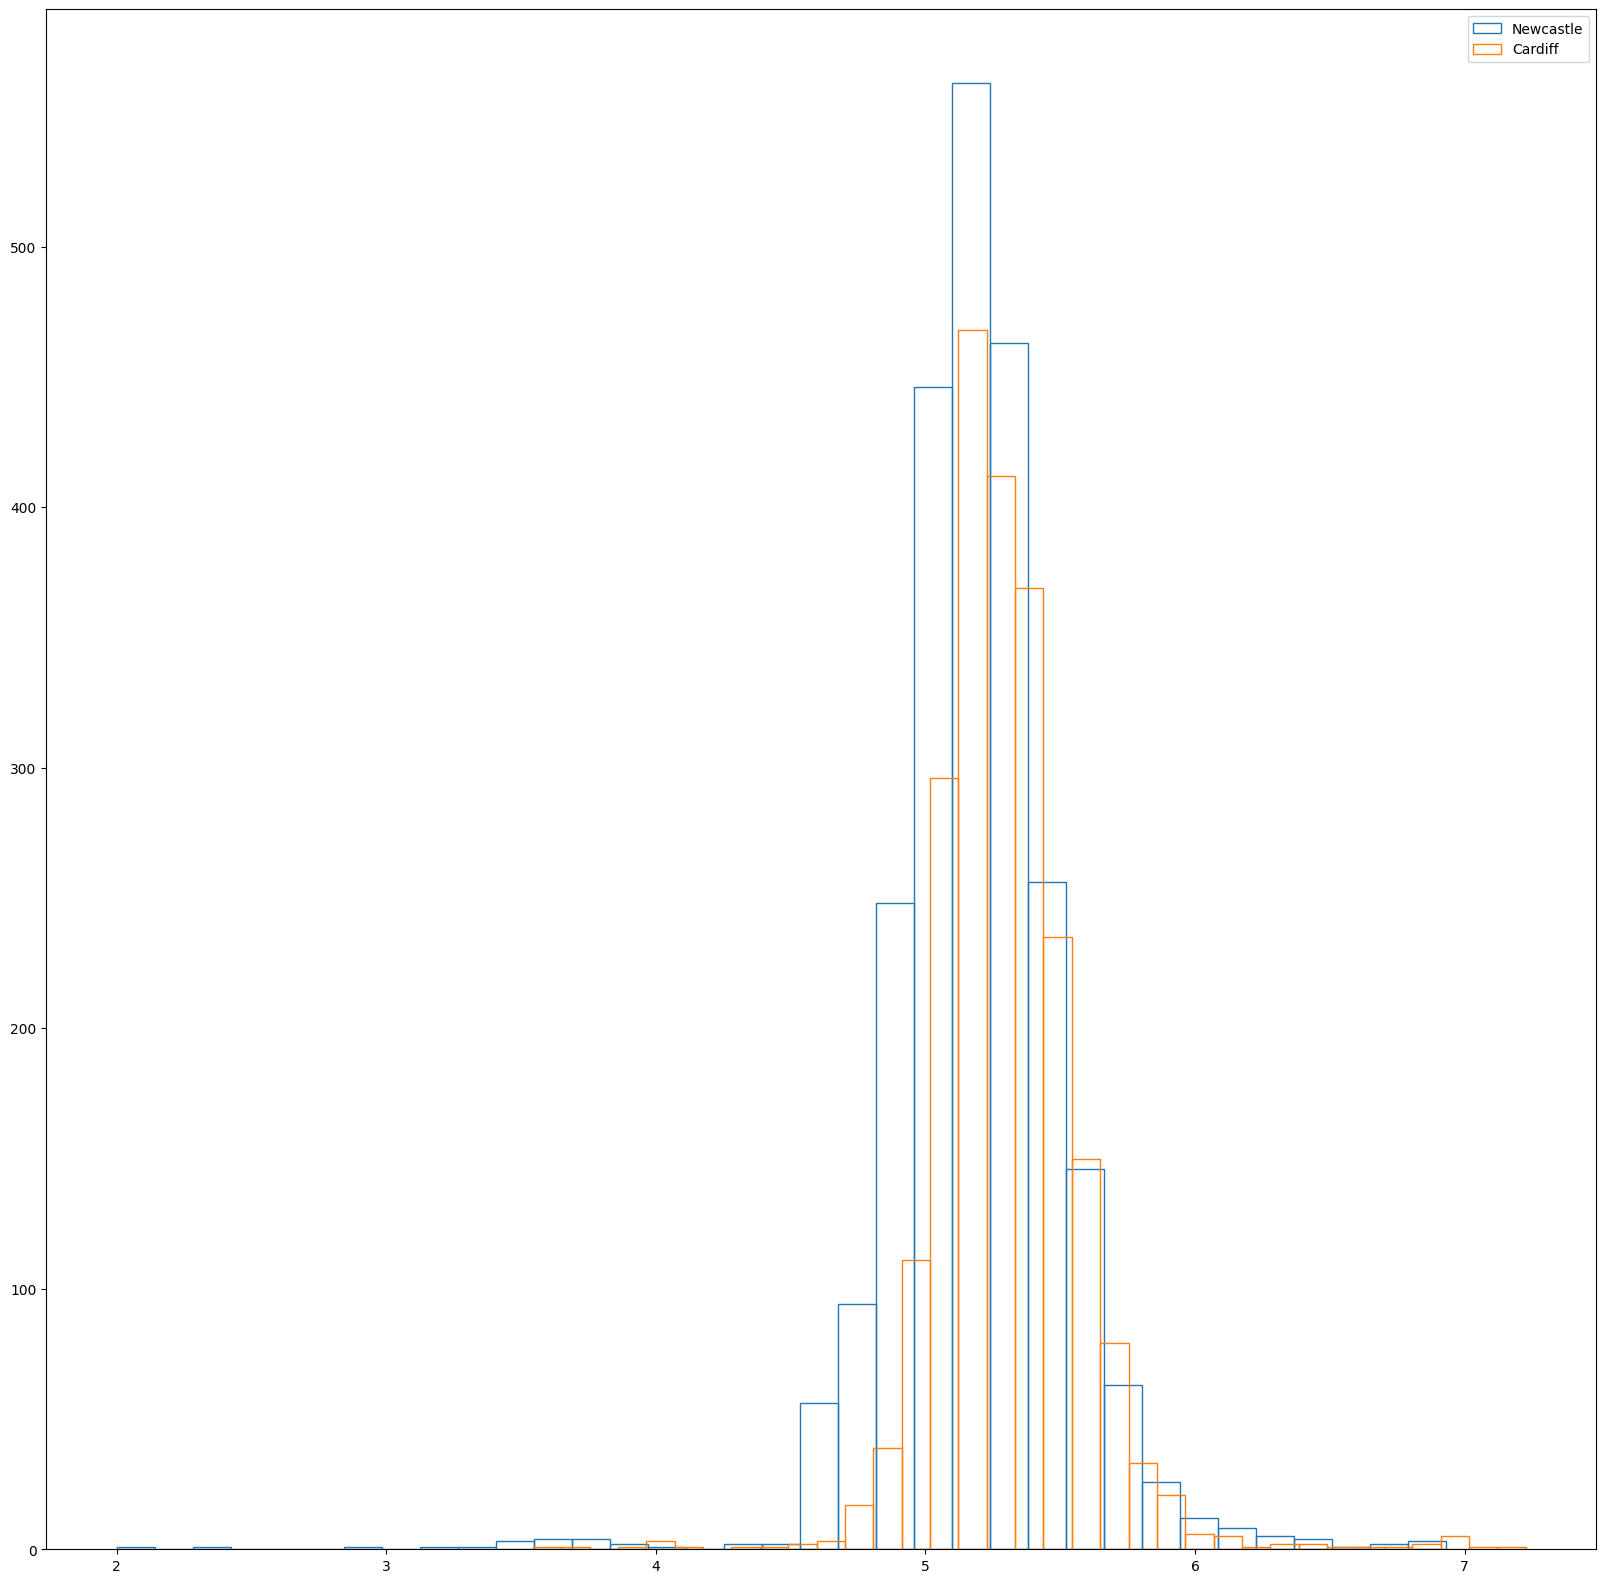

In [150]:
fig, ax = plt.subplots(figsize=(20,20))
style = {'facecolor': 'none', 'edgecolor': 'C0', 'linewidth': 1}
plt.hist(prices_new['price_log10'], label='Newcastle', bins=35, **style)
style = {'facecolor': 'none', 'edgecolor': 'C1', 'linewidth': 1}
plt.hist(prices_car['price_log10'], label='Cardiff', bins=35, **style)
plt.legend()

We make the hypothesis living in Newcastle does not impact purchasing a property in Newcastle.

$H_0$ is _"Living in Newcastle does not impact on purchasing a property in Newcastle"_.  

$H_1$ is _"Living in Newcastle impact on purchasing a property in Newcastle"_. 

We use a p-value of 0.05. 

M = is the mean sample from 2016

mu = population mean

sigma = population standard deviation

In [152]:
n = prices_car.shape[0]
mu = prices_car['Price'].describe()['mean']
sigma  = prices_car['Price'].describe()['std']
M = prices_new['Price'].describe()['mean']
denominator = sigma / math.sqrt(n)
numerator   = mu - M
Z           = numerator / denominator
Z


4.200810519677297

In [153]:
import scipy.stats

#find p-value for two-tailed test
p_value = scipy.stats.norm.sf(abs(Z))*2
print("p value " , p_value)
if p_value < 0.05:
    print("Reject Null hypothesis")
else:
    print("Fail to reject Null hypothesis")


p value  2.659611145852547e-05
Reject Null hypothesis


As the p-value is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected. This means that living in Cardiff may impact on purchasing a property in Newcastle. However, further research on other aspects that may affect the purchase of property needs to be explored.



[The standardise measure of the effect](https://en.wikipedia.org/wiki/Effect_size#Cohen.27s_d) is computed.

In [154]:
# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
 # calculate the size of samples
 n1, n2 = len(d1), len(d2)
 # calculate the variance of the samples
 s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
 # calculate the pooled standard deviation
 s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
 # calculate the means of the samples
 u1, u2 = np.mean(d1), np.mean(d2)
 # calculate the effect size
 return abs((u1 - u2) / s)

In [157]:
cohen_d = cohend(prices_car['Price'], prices_new['Price'])
print("d value : ", cohen_d)
if cohen_d == 0 :
    print('no effect')
elif cohen_d < 0.20:
    print('small effect')
elif cohen_d < 0.80:
    print('medium effect')
elif cohen_d < 1:
    print('large effect')

d value :  0.1086453967263697
small effect


We are completing a t-test with the following hypothesis.

$H_0 = \mu_{cardiff} = \mu_{newcastle}$

$H_1 = \mu_{cardiff} \neq \mu_{newcastle}$

$p  = 0.05$

We have shown that both distributions have not the same paramteters. The p-value is $2e-4$, which is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected.  The mean average of Cardiff and Newcastle are not equal. 



In [158]:
ttest_ind(prices_car['Price'], prices_new['Price'])

(3.718781924342659, 0.00020252470495357115, 4689.0)

In [159]:
temp

,Cardiff,Newcastle
count,2.272000e+03,2.419000e+03
mean,2.715237e+05,2.135305e+05
std,6.580335e+05,3.818970e+05
min,3.500000e+03,1.000000e+02
25%,1.399988e+05,1.100000e+05
50%,1.850000e+05,1.530000e+05
75%,2.660000e+05,2.250000e+05
max,1.682620e+07,8.538000e+06


# Cambridge: exploring further the market with a simulation

[Cambridge City Council](https://democracy.cambridge.gov.uk/documents/s59775/220628%20State%20of%20the%20City%20Report%20Committee%20Final.pdf) estimates the number of properties as 56,000 approximately.  We could explore further the potential values of properties with a simulation.  [ONS](https://www.ons.gov.uk/visualisations/housingpriceslocal/E07000008/) estimates in June 2024, the expected property value is approximately £494,000.

We generate a population using this values to simulate the market in 2024. We estimate the standard deviation as 8.0e+5. This simulate should be considered as unreliable and inaccurate. It can be used to compare the 2016 samples to the current values.

In [167]:
mu = 494000
sigma  = 5.0e5
M = prices_cam['Price'].describe()['mean']
sim_pop_cam = np.random.normal(mu, sigma, 56000)
pos = pd.Series(sim_pop_cam[sim_pop_cam > 0])
neg = pd.Series(sim_pop_cam[sim_pop_cam < 0] * -1)
pop_cam = pd.DataFrame(pd.concat([pos, neg], axis=0))
pop_cam.columns = ['0']
pop_cam['price_log10'] = np.log10(pop_cam['0'])


temp = pd.DataFrame()
temp['Population'] = pop_cam.describe()['0']
temp['Sample'] = prices_cam['Price'].describe()
temp


,Population,Sample
count,5.600000e+04,1.639000e+03
mean,5.768144e+05,4.853539e+05
std,3.976024e+05,7.475032e+05
min,1.856553e+01,1.000000e+02
25%,2.529677e+05,2.950000e+05
50%,5.185646e+05,3.950000e+05
75%,8.327465e+05,5.250000e+05
max,2.613715e+06,1.853410e+07


In [101]:
pop_cam.dtypes


0              float64
price_log10    float64
dtype: object

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log10', ylabel='Count'>

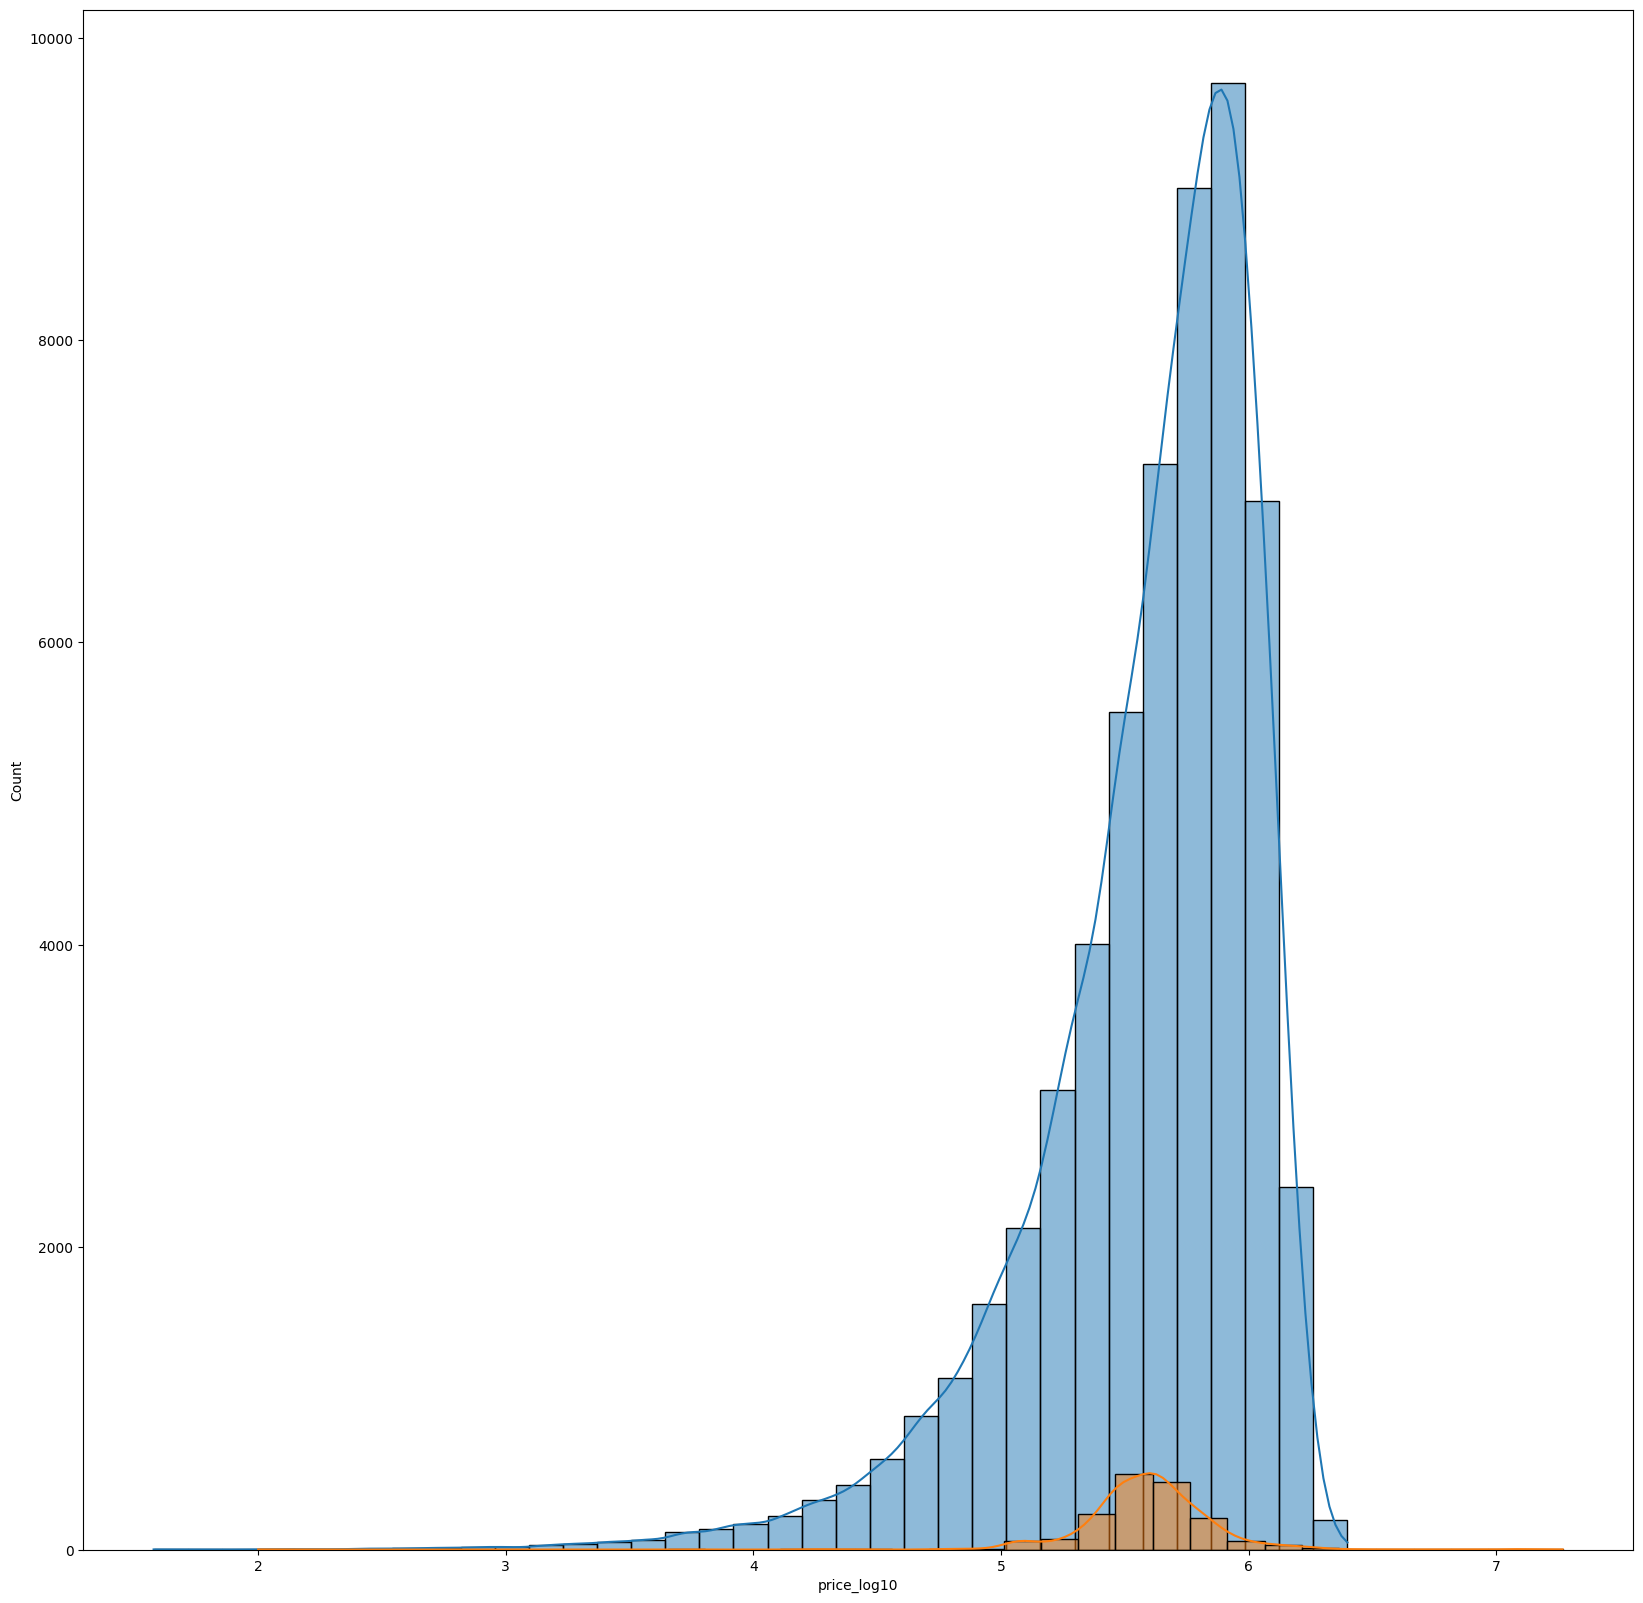

In [102]:
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(pop_cam, x="price_log10", bins=35, ax=ax, kde=True)
sns.histplot(prices_cam, x="price_log10", bins=35, ax=ax, kde=True)

__Suggested readings:__



We make the hypothesis customers are will to pay the same price as the 2016 mean property price. 

$H_0$ is _"customers are not willing to pay 485,000('GDP') for a property in Cambridge"_.  

$H_1$ is _"customers are willing to pay 485,000('GDP') for a property in Cambridge"_. 

We use a p-value of 0.05. 

M = is the mean sample from 2016

mu = population mean

sigma = population standard deviation

In [103]:
n = prices_cam.shape[0]

denominator = sigma / math.sqrt(n)
numerator   = mu - M
Z           = numerator / denominator
Z


0.700063988041035

In [104]:
import scipy.stats

#find p-value for two-tailed test
p_value = scipy.stats.norm.sf(abs(Z))*2
print("p value " , p_value)
if p_value < 0.05:
    print("Reject Null hypothesis")
else:
    print("Fail to reject Null hypothesis")


p value  0.4838873443061166
Fail to reject Null hypothesis


As the p-value (0.66) is greater than 0.05. The deviation from the null hypothesis is not statistically significant, and the null hypothesis is not rejected. This means that customers are not willing to pay 485,000('GDP') for a property in Cambridge. 



[The standardise measure of the effect](https://en.wikipedia.org/wiki/Effect_size#Cohen.27s_d) is computed.

In [105]:
# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
 # calculate the size of samples
 n1, n2 = len(d1), len(d2)
 # calculate the variance of the samples
 s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
 # calculate the pooled standard deviation
 s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
 # calculate the means of the samples
 u1, u2 = np.mean(d1), np.mean(d2)
 # calculate the effect size
 return abs((u1 - u2) / s)

In [106]:
cohen_d = cohend(prices_cam['Price'], pop_cam.loc[:,'0'])
if cohen_d == 0 :
    print('no effect')
elif cohen_d < 0.20:
    print('small effect')
elif cohen_d < 0.80:
    print('medium effect')
elif cohen_d < 1:
    print('large effect')

medium effect


We are completing a t-test with the following hypothesis.

$H_0 = \mu_{population} = \mu_{sample}$

$H_1 = \mu_{population} \neq \mu_{sample}$

$p  = 0.05$

We have shown that the sample may have not similar parameters than the population. The p-value is $1.97e-18$, which is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected.  



In [136]:
ttest_ind(prices_cam['Price'], pop_cam.loc[:,'0'])

(-8.76196934554272, 1.969626189119333e-18, 57637.0)

In [137]:
temp


,Population,Sample
count,5.600000e+04,1.639000e+03
mean,5.755582e+05,4.853539e+05
std,3.966924e+05,7.475032e+05
min,3.782733e+01,1.000000e+02
25%,2.527190e+05,2.950000e+05
50%,5.177231e+05,3.950000e+05
75%,8.342607e+05,5.250000e+05
max,2.504144e+06,1.853410e+07


# Newcastle: exploring further the market with a simulation

[Newcastle areas](https://newcastleareas.wordpress.com/tag/statistics/) estimates the number of properties as 124,000 approximately.  We could explore further the potential values of properties with a simulation.  [ONS](https://www.ons.gov.uk/visualisations/housingpriceslocal/E07000008/) estimates in June 2024, the expected property value is approximately £193,000.

We generate a population using this values to simulate the market in 2024. We estimate the standard deviation as 4.0e+5. This simulate should be considered as unreliable and inaccurate. It can be used to compare the 2016 samples to the current values.

In [174]:
mu = 193000
sigma  = 4.0e5
M = prices_new['Price'].describe()['mean']
sim_pop_new = np.random.normal(mu, sigma, 124000)
pos = pd.Series(sim_pop_new[sim_pop_new > 0])
neg = pd.Series(sim_pop_new[sim_pop_new < 0] * -1)
pop_new = pd.DataFrame(pd.concat([pos, neg], axis=0))
pop_new.columns = ['0']
pop_new['price_log10'] = np.log10(pop_new['0'])


temp = pd.DataFrame()
temp['Population'] = pop_new.describe()['0']
temp['Sample'] = prices_new['Price'].describe()
temp


,Population,Sample
count,1.240000e+05,2.419000e+03
mean,3.563039e+05,2.135305e+05
std,2.663947e+05,3.818970e+05
min,1.956628e+00,1.000000e+02
25%,1.432887e+05,1.100000e+05
50%,3.038871e+05,1.530000e+05
75%,5.153732e+05,2.250000e+05
max,1.950115e+06,8.538000e+06


In [164]:
pop_new.dtypes


0              float64
price_log10    float64
dtype: object

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log10', ylabel='Count'>

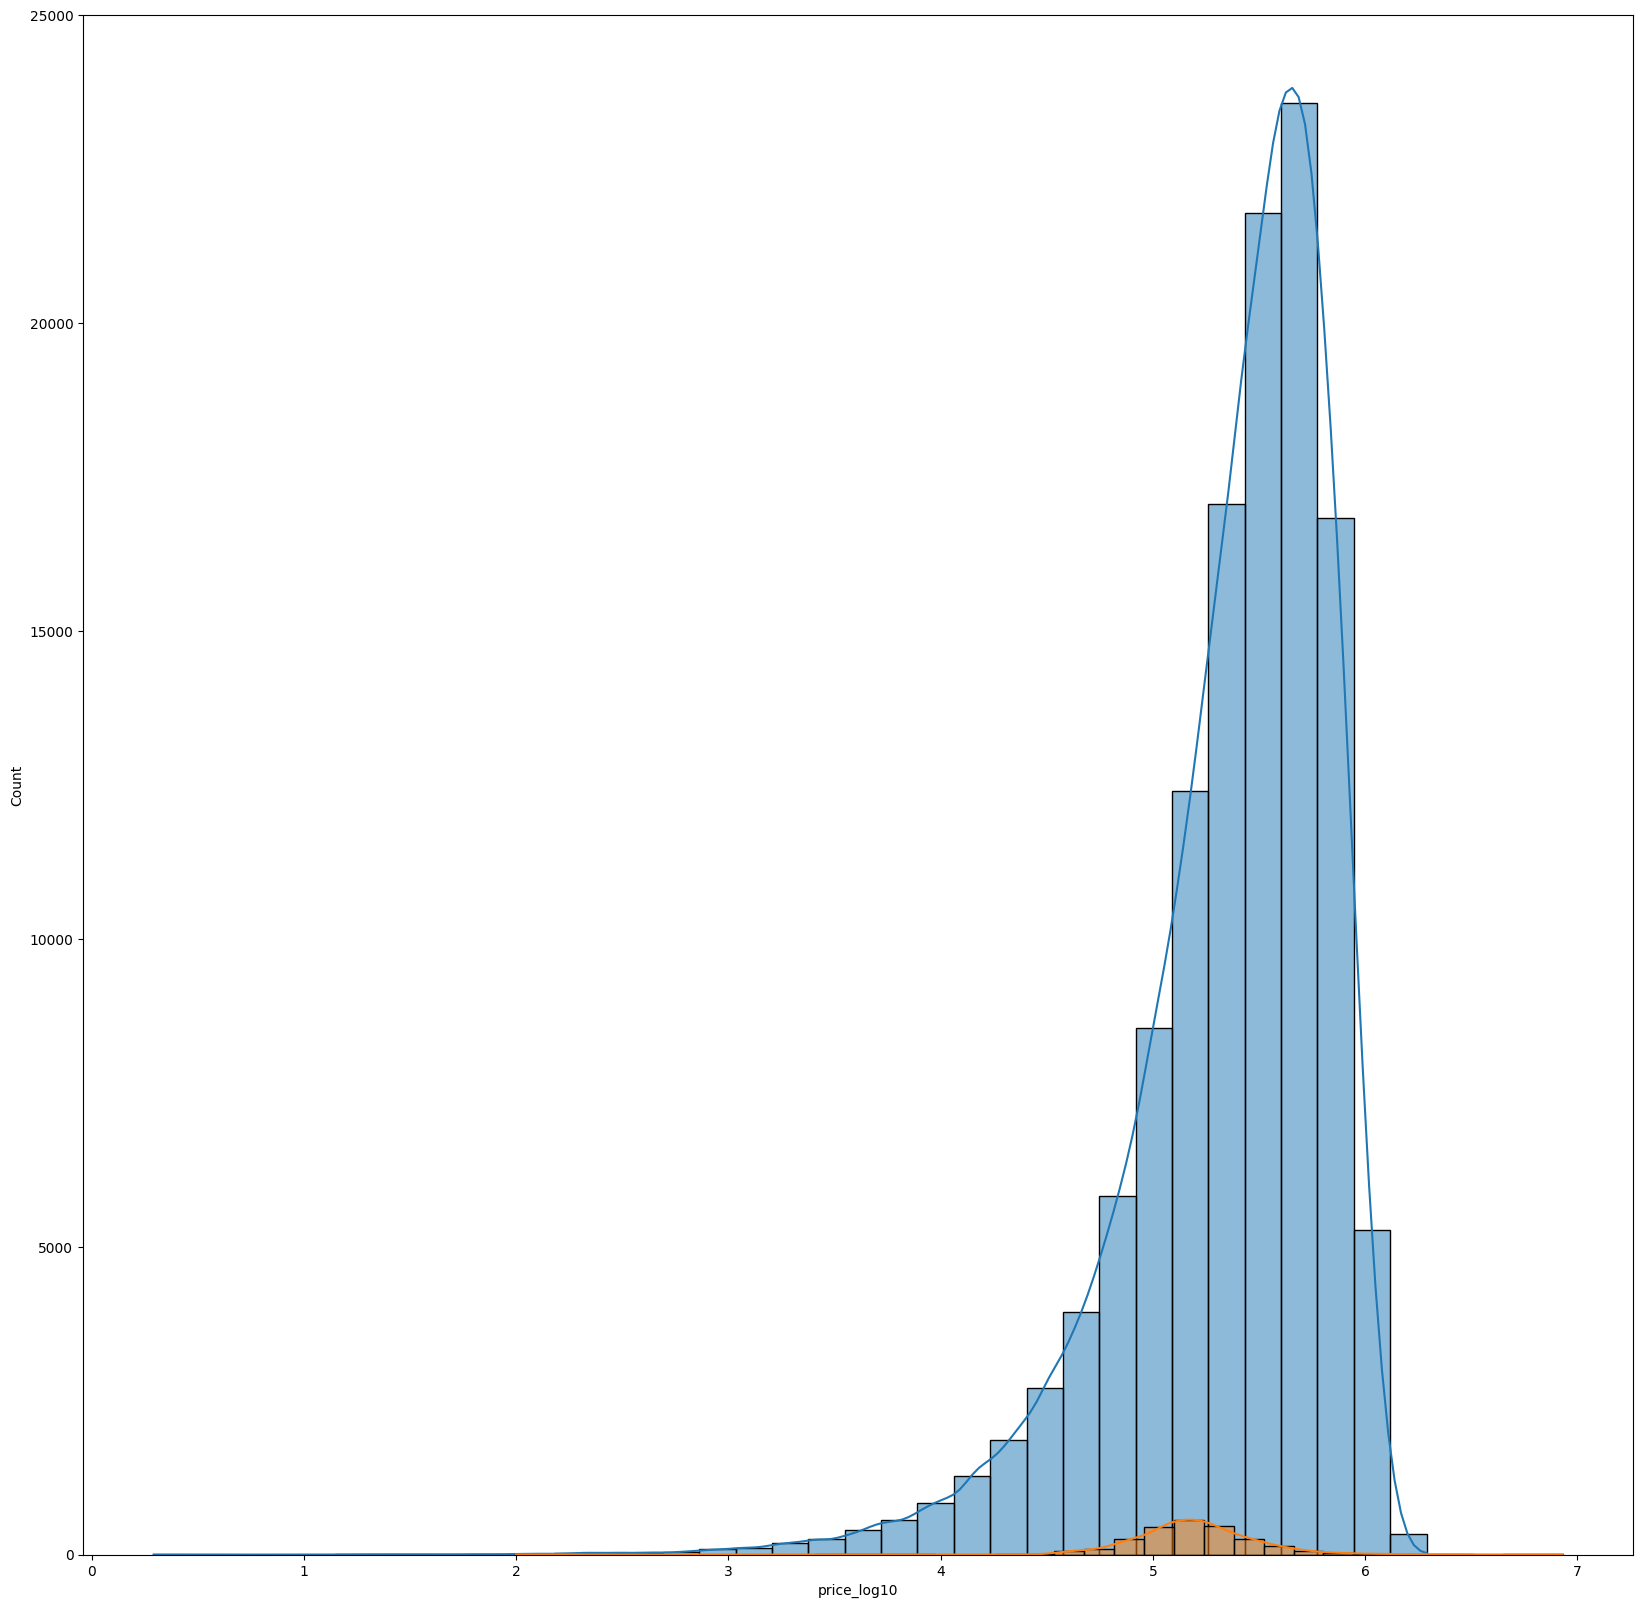

In [175]:
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(pop_new, x="price_log10", bins=35, ax=ax, kde=True)
sns.histplot(prices_new, x="price_log10", bins=35, ax=ax, kde=True)

__Suggested readings:__



We make the hypothesis customers are will to pay the same price as the 2016 mean property price. 

$H_0$ is _"customers are not willing to pay 213,000('GDP') for a property in Cambridge"_.  

$H_1$ is _"customers are willing to pay 213,000('GDP') for a property in Cambridge"_. 

We use a p-value of 0.05. 

M = is the mean sample from 2016

mu = population mean

sigma = population standard deviation

In [103]:
n = prices_cam.shape[0]

denominator = sigma / math.sqrt(n)
numerator   = mu - M
Z           = numerator / denominator
Z


0.700063988041035

In [176]:
import scipy.stats

#find p-value for two-tailed test
p_value = scipy.stats.norm.sf(abs(Z))*2
print("p value " , p_value)
if p_value < 0.05:
    print("Reject Null hypothesis")
else:
    print("Fail to reject Null hypothesis")


p value  2.659611145852547e-05
Reject Null hypothesis


As the p-value ($2.7e-05$) is small than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected. This means that customers are willing to pay 213,000('GDP') for a property in Newcastle. 



[The standardise measure of the effect](https://en.wikipedia.org/wiki/Effect_size#Cohen.27s_d) is computed.

In [178]:
# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
 # calculate the size of samples
 n1, n2 = len(d1), len(d2)
 # calculate the variance of the samples
 s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
 # calculate the pooled standard deviation
 s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
 # calculate the means of the samples
 u1, u2 = np.mean(d1), np.mean(d2)
 # calculate the effect size
 return abs((u1 - u2) / s)

In [181]:
cohen_d = cohend(prices_new['Price'], pop_new.loc[:,'0'])
if cohen_d == 0 :
    print('no effect')
elif cohen_d < 0.20:
    print('small effect')
elif cohen_d < 0.80:
    print('medium effect')
elif cohen_d < 1:
    print('large effect')

medium effect


We are completing a t-test with the following hypothesis.

$H_0 = \mu_{population} = \mu_{sample}$

$H_1 = \mu_{population} \neq \mu_{sample}$

$p  = 0.05$

We have shown that the sample may have not similar parameters than the population. The p-value is $6.40e-147$, which is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected.  



In [182]:
ttest_ind(prices_new['Price'], pop_new.loc[:,'0'])

(-25.846722707232583, 6.398898902230204e-147, 126417.0)

In [183]:
temp


,Population,Sample
count,1.240000e+05,2.419000e+03
mean,3.563039e+05,2.135305e+05
std,2.663947e+05,3.818970e+05
min,1.956628e+00,1.000000e+02
25%,1.432887e+05,1.100000e+05
50%,3.038871e+05,1.530000e+05
75%,5.153732e+05,2.250000e+05
max,1.950115e+06,8.538000e+06


# Cardiff : exploring further the market with a simulation

[The Welsh](https://senedd.wales/media/gkyfkfiq/cardiff-english.pdf) estimates the number of properties as 123,600 approximately.  We could explore further the potential values of properties with a simulation.  [ONS](https://www.ons.gov.uk/visualisations/housingpriceslocal/E07000008/) estimates in June 2024, the expected property value is approximately £259,000.

We generate a population using this values to simulate the market in 2024. We estimate the standard deviation as 7.0e+5. This simulate should be considered as unreliable and inaccurate. It can be used to compare the 2016 samples to the current values.

In [192]:
mu = 259000
sigma  = 7.0e5
M = prices_car['Price'].describe()['mean']
sim_pop_car = np.random.normal(mu, sigma, 123600)
pos = pd.Series(sim_pop_car[sim_pop_car > 0])
neg = pd.Series(sim_pop_car[sim_pop_car < 0] * -1)
pop_car = pd.DataFrame(pd.concat([pos, neg], axis=0))
pop_car.columns = ['0']
pop_car['price_log10'] = np.log10(pop_car['0'])


temp = pd.DataFrame()
temp['Population'] = pop_car.describe()['0']
temp['Sample'] = prices_car['Price'].describe()
temp


,Population,Sample
count,1.236000e+05,2.272000e+03
mean,5.958754e+05,2.715237e+05
std,4.480032e+05,6.580335e+05
min,4.283022e+00,3.500000e+03
25%,2.395459e+05,1.399988e+05
50%,5.052723e+05,1.850000e+05
75%,8.580070e+05,2.660000e+05
max,3.372173e+06,1.682620e+07


In [188]:
pop_car.dtypes


0              float64
price_log10    float64
dtype: object

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_log10', ylabel='Count'>

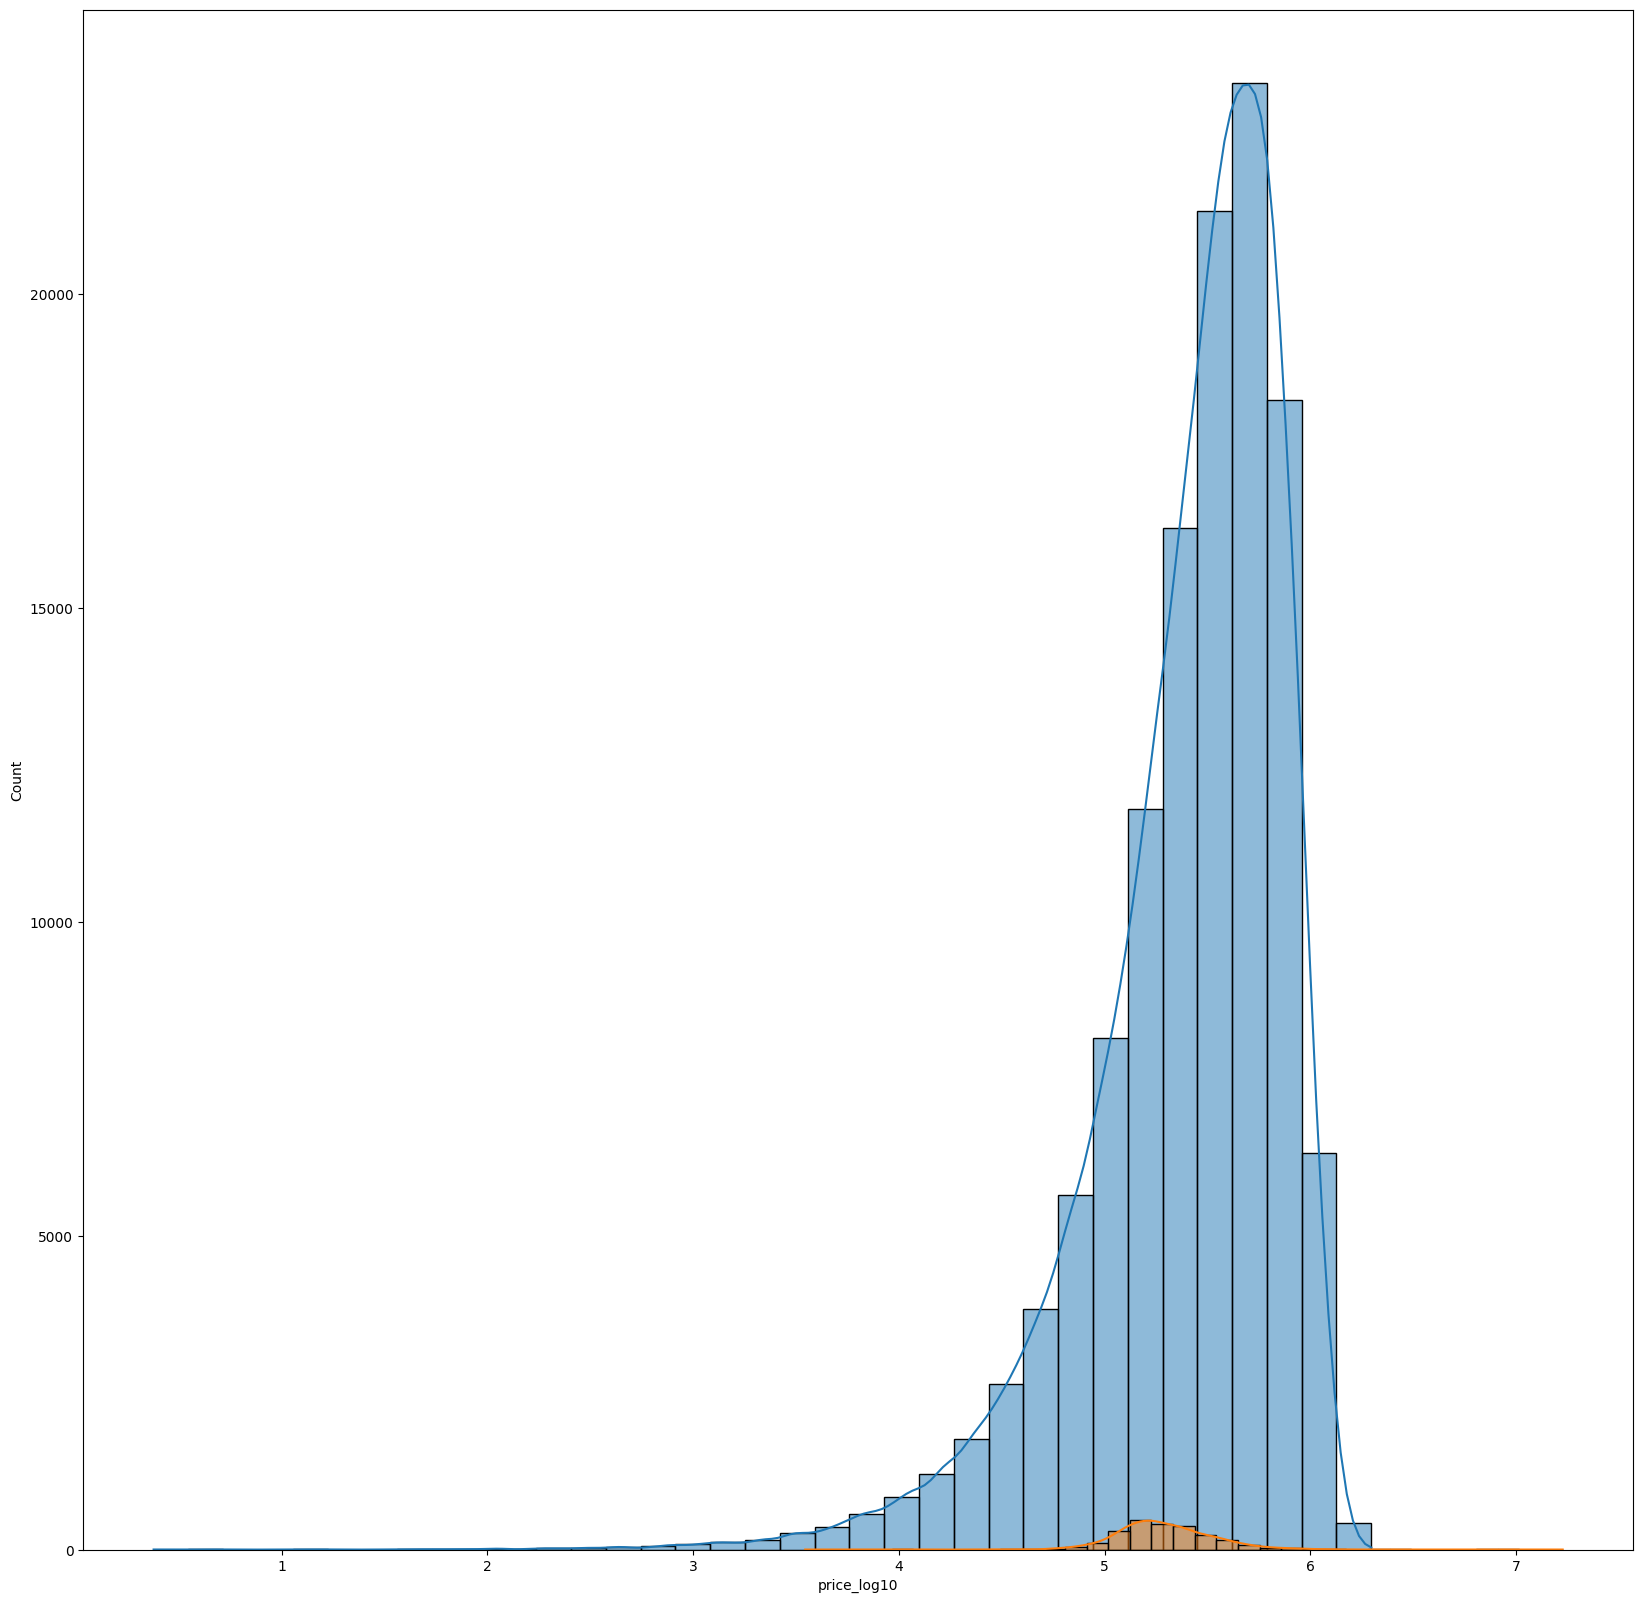

In [189]:
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(pop_car, x="price_log10", bins=35, ax=ax, kde=True)
sns.histplot(prices_car, x="price_log10", bins=35, ax=ax, kde=True)

__Suggested readings:__



We make the hypothesis customers are will to pay the same price as the 2016 mean property price. 

$H_0$ is _"customers are not willing to pay 259,000('GDP') for a property in Cambridge"_.  

$H_1$ is _"customers are willing to pay 259,000('GDP') for a property in Cambridge"_. 

We use a p-value of 0.05. 

M = is the mean sample from 2016

mu = population mean

sigma = population standard deviation

In [193]:
n = prices_cam.shape[0]

denominator = sigma / math.sqrt(n)
numerator   = mu - M
Z           = numerator / denominator
Z


-0.724311047041326

In [194]:
import scipy.stats

#find p-value for two-tailed test
p_value = scipy.stats.norm.sf(abs(Z))*2
print("p value " , p_value)
if p_value < 0.05:
    print("Reject Null hypothesis")
else:
    print("Fail to reject Null hypothesis")


p value  0.4688747964184091
Fail to reject Null hypothesis


As the p-value ($4.6e-01$) is greater than 0.05. The deviation from the null hypothesis is not statistically significant, and the null hypothesis is not rejected. This means that customers are willing to pay 259,000('GDP') for a property in Cardiff. 



[The standardise measure of the effect](https://en.wikipedia.org/wiki/Effect_size#Cohen.27s_d) is computed.

In [195]:
# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
 # calculate the size of samples
 n1, n2 = len(d1), len(d2)
 # calculate the variance of the samples
 s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
 # calculate the pooled standard deviation
 s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
 # calculate the means of the samples
 u1, u2 = np.mean(d1), np.mean(d2)
 # calculate the effect size
 return abs((u1 - u2) / s)

In [197]:
cohen_d = cohend(prices_car['Price'], pop_car.loc[:,'0'])
if cohen_d == 0 :
    print('no effect')
elif cohen_d < 0.20:
    print('small effect')
elif cohen_d < 0.80:
    print('medium effect')
elif cohen_d < 1:
    print('large effect')

medium effect


We are completing a t-test with the following hypothesis.

$H_0 = \mu_{population} = \mu_{sample}$

$H_1 = \mu_{population} \neq \mu_{sample}$

$p  = 0.05$

We have shown that the sample may have not similar parameters than the population. The p-value is $5.73e-250$, which is smaller than 0.05. The deviation from the null hypothesis is statistically significant, and the null hypothesis is rejected.  



In [199]:
ttest_ind(prices_car['Price'], pop_car.loc[:,'0'])

(-33.84511372363306, 5.73702904778408e-250, 125870.0)

In [200]:
temp


,Population,Sample
count,1.236000e+05,2.272000e+03
mean,5.958754e+05,2.715237e+05
std,4.480032e+05,6.580335e+05
min,4.283022e+00,3.500000e+03
25%,2.395459e+05,1.399988e+05
50%,5.052723e+05,1.850000e+05
75%,8.580070e+05,2.660000e+05
max,3.372173e+06,1.682620e+07
